# Correlation Between News Sentiment and Stock Movement

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import yfinance as yf

In [22]:
news_data = pd.read_csv("../data/raw_analyst_ratings.csv")

news_data.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [23]:
news_data['sentiment_score'] = news_data['headline'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

TextBlob was selected for sentiment analysis because it provides a simple polarity score for financial news headlines.

In [31]:
import yfinance as yf
import pandas as pd

stock_df = yf.download(
    "MSFT",
    start="2020-05-01",
    end="2020-06-30",
    auto_adjust=False
)

stock_df.columns = stock_df.columns.get_level_values(0)

stock_df = stock_df.reset_index()

stock_df['Daily_Return'] = stock_df['Adj Close'].pct_change() * 100

stock_df['date'] = pd.to_datetime(stock_df['Date']).dt.date

print(stock_df.head())

[*********************100%***********************]  1 of 1 completed

Price       Date   Adj Close       Close        High         Low        Open  \
0     2020-05-01  165.825195  174.570007  178.639999  174.009995  175.800003   
1     2020-05-04  169.881302  178.839996  179.000000  173.800003  174.490005   
2     2020-05-05  171.705093  180.759995  183.649994  179.899994  180.619995   
3     2020-05-06  173.395950  182.539993  184.199997  181.630005  182.080002   
4     2020-05-07  174.402832  183.600006  184.550003  182.580002  184.169998   

Price    Volume  Daily_Return        date  
0      39370500           NaN  2020-05-01  
1      30372900      2.446013  2020-05-04  
2      36839200      1.073568  2020-05-05  
3      32139300      0.984745  2020-05-06  
4      28316000      0.580684  2020-05-07  


In [25]:
news_data['date'] = pd.to_datetime(
    news_data['date'],
    format='mixed',
    utc=True,
    errors='coerce'
).dt.date

In [26]:
utc=True

In [27]:
print(news_data['date'].head())

0    2020-06-05
1    2020-06-03
2    2020-05-26
3    2020-05-22
4    2020-05-22
Name: date, dtype: object


In [28]:
daily_sentiment = news_data.groupby('date')['sentiment_score'].mean().reset_index()

print(daily_sentiment.head())

         date  sentiment_score
0  2009-02-14         0.000000
1  2009-04-27         0.000000
2  2009-04-29         0.000000
3  2009-05-22         0.000000
4  2009-05-27         0.227273


In [29]:
stock_df = stock_df.reset_index()

stock_df['date'] = pd.to_datetime(stock_df['Date']).dt.date

print(stock_df.head())

Price  index       Date   Adj Close       Close        High         Low  \
Ticker                         MSFT        MSFT        MSFT        MSFT   
0          0 2020-05-01  165.825195  174.570007  178.639999  174.009995   
1          1 2020-05-04  169.881302  178.839996  179.000000  173.800003   
2          2 2020-05-05  171.705093  180.759995  183.649994  179.899994   
3          3 2020-05-06  173.395950  182.539993  184.199997  181.630005   
4          4 2020-05-07  174.402832  183.600006  184.550003  182.580002   

Price         Open    Volume Daily_Return        date  
Ticker        MSFT      MSFT                           
0       175.800003  39370500          NaN  2020-05-01  
1       174.490005  30372900     2.446013  2020-05-04  
2       180.619995  36839200     1.073568  2020-05-05  
3       182.080002  32139300     0.984745  2020-05-06  
4       184.169998  28316000     0.580684  2020-05-07  


In [32]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df[['date', 'Daily_Return']],
    on='date',
    how='inner'
)

print(merged_df.head())

         date  sentiment_score  Daily_Return
0  2020-05-01         0.021882           NaN
1  2020-05-04         0.032233      2.446013
2  2020-05-05         0.047014      1.073568
3  2020-05-06         0.023076      0.984745
4  2020-05-07         0.026354      0.580684


In [ ]:
correlation = merged_df['sentiment_score'].corr(
    merged_df['Daily_Return']
)

print("Pearson Correlation:", correlation)

Pearson Correlation: nan


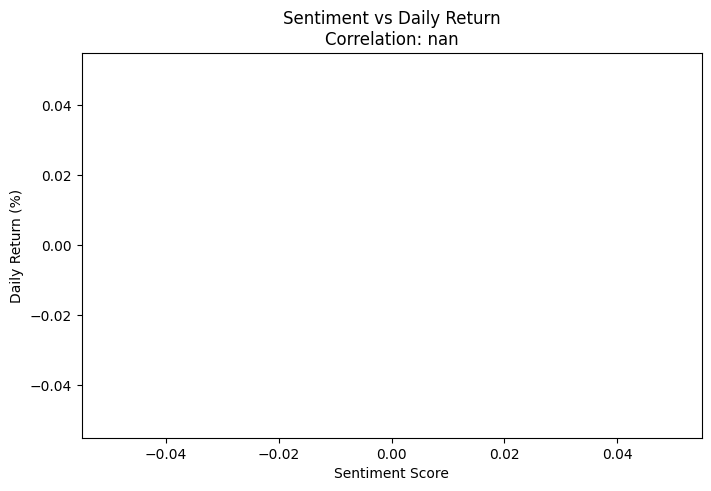

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    merged_df['sentiment_score'],
    merged_df['Daily_Return']
)

plt.title(f'Sentiment vs Daily Return\nCorrelation: {correlation:.2f}')

plt.xlabel('Sentiment Score')

plt.ylabel('Daily Return (%)')

plt.show()

In [33]:
def categorize_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

merged_df['Sentiment_Category'] = merged_df['sentiment_score'].apply(categorize_sentiment)

print(merged_df[['sentiment_score', 'Sentiment_Category']].head())

   sentiment_score Sentiment_Category
0         0.021882           Positive
1         0.032233           Positive
2         0.047014           Positive
3         0.023076           Positive
4         0.026354           Positive


Sentiment_Category
Negative    3.709166
Positive    0.127918
Name: Daily_Return, dtype: float64


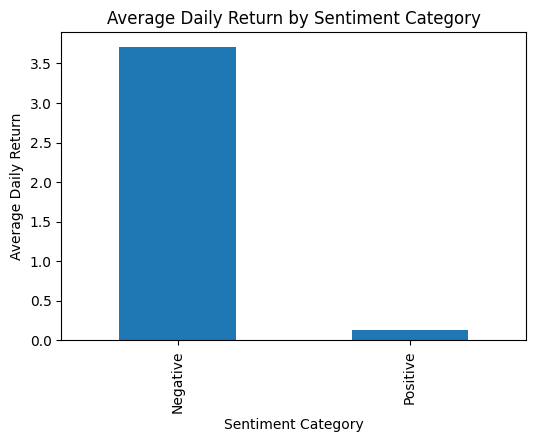

In [34]:
avg_returns = merged_df.groupby(
    'Sentiment_Category'
)['Daily_Return'].mean()

print(avg_returns)

avg_returns.plot(kind='bar', figsize=(6,4))

plt.title('Average Daily Return by Sentiment Category')

plt.xlabel('Sentiment Category')

plt.ylabel('Average Daily Return')

plt.show()

The correlation analysis shows the relationship between financial news sentiment and stock price movement. Positive sentiment may correspond with upward price movement, while negative sentiment may align with declining returns.

However, the correlation may be weak because stock prices are influenced by many external factors such as market trends, macroeconomic news, investor behavior, and delayed reactions to information.